## Setup
Note that the java runtime environment must be installed on your system to run this code. If you are using Homebrew on macOS, you can install OpenJDK 17 with the following command:

```
brew install openjdk@17
```

In [7]:
"""
Option 3: Building Distributions with Apache Spark
This notebook demonstrates computing distributions using Spark for distributed processing
"""

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, stddev, min as spark_min, max as spark_max
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from utils import DB_PARAMS


In [8]:
NUM_PARTITIONS = 100
NUM_BINS = 100

Apache Spark Distribution Analysis
Spark version: 4.1.1
Loading data with 5 partitions...


Loaded 1,000,000 rows in 0.85 seconds
Number of partitions: 5

Computing basic statistics...

Basic Statistics (computed in 0.06 seconds):
  Count:  1,000,000
  Min:    20.0461
  Max:    79.9533
  Mean:   50.0292
  StdDev: 12.2472

Computing histogram with 50 bins...


Histogram computed in 1.95 seconds
Histogram saved to histogram_spark.png

Computing approximate percentiles (error=0.01)...
Percentiles (computed in 0.24 seconds):
  P01: 20.0461
  P05: 29.9486
  P25: 41.4518
  P50: 49.7528
  P75: 58.7683
  P95: 70.4281
  P99: 79.9533

Computing grouped distributions...
Grouped statistics (computed in 0.18 seconds):

Category: A
  Count:  200,193
  Mean:   50.0569
  StdDev: 12.2541
  Min:    20.1182
  Max:    79.9191

Category: B
  Count:  199,615
  Mean:   50.0342
  StdDev: 12.2507
  Min:    20.0726
  Max:    79.8843

Category: C
  Count:  200,339
  Mean:   49.9914
  StdDev: 12.2498
  Min:    20.0921
  Max:    79.9533

Category: D
  Count:  199,798
  Mean:   50.0313
  StdDev: 12.2423
  Min:    20.0461
  Max:    79.8696

Category: E
  Count:  200,055
  Mean:   50.0325
  StdDev: 12.2392
  Min:    20.1526
  Max:    79.9104

Computing top 20 most frequent values...
Top 20 values (computed in 0.09 seconds):
  1. C: 200,339
  2. A: 200,193
  3. E: 200,055


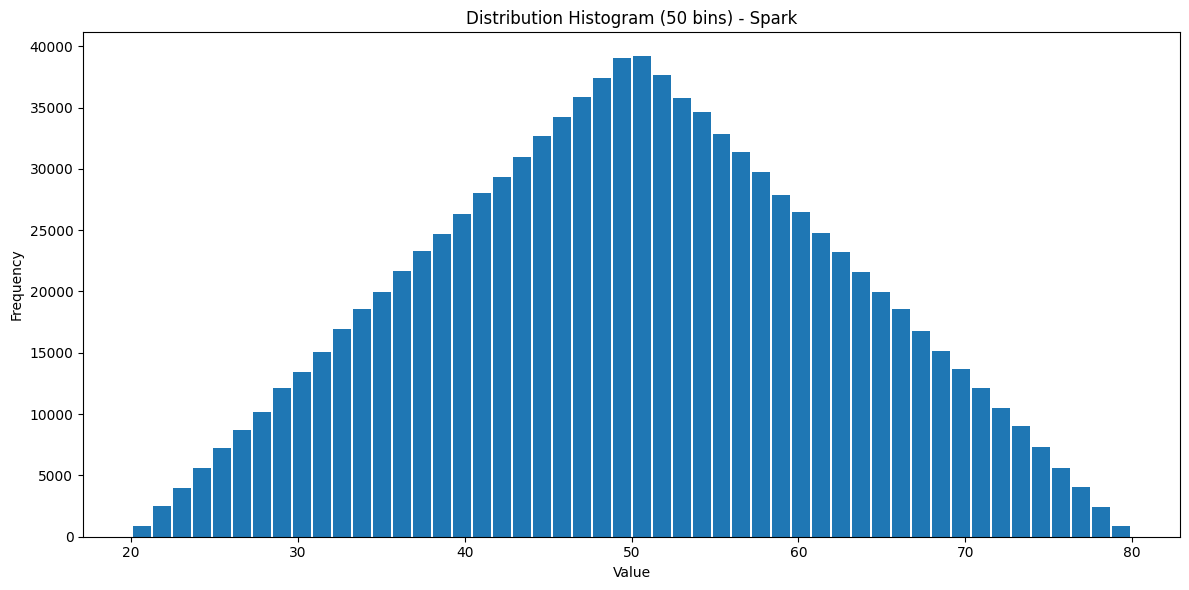

In [9]:

# ============================================================================
# 1. SPARK SESSION SETUP
# ============================================================================

def create_spark_session():
    """Initialize Spark session with JDBC support"""
    import os

    
    # Download PostgreSQL JDBC driver if needed
    jdbc_jar = "postgresql-42.6.0.jar"
    if not os.path.exists(jdbc_jar):
        print(f"Downloading PostgreSQL JDBC driver...")
        import urllib.request
        url = "https://jdbc.postgresql.org/download/postgresql-42.6.0.jar"
        urllib.request.urlretrieve(url, jdbc_jar)
        print(f"Downloaded {jdbc_jar}")
    
    # Get absolute path for JDBC jar
    jdbc_jar_path = os.path.abspath(jdbc_jar)
    
    spark = SparkSession.builder \
        .appName("Distribution Analysis") \
        .config("spark.jars", jdbc_jar_path) \
        .config("spark.executor.memory", "2g") \
        .config("spark.driver.memory", "2g") \
        .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
        .config("spark.driver.extraJavaOptions", "-Djdk.security.auth.subject.enable=true") \
        .config("spark.executor.extraJavaOptions", "-Djdk.security.auth.subject.enable=true") \
        .master("local[*]") \
        .getOrCreate()
    
    print(f"Spark version: {spark.version}")
    return spark

# Database connection properties
jdbc_url = f"jdbc:postgresql://{DB_PARAMS['host']}:5432/{DB_PARAMS['database']}"
connection_properties = {
    "user": DB_PARAMS["user"],
    "password": DB_PARAMS["password"],
    "driver": "org.postgresql.Driver"
}

# ============================================================================
# 2. DATA LOADING WITH PARTITIONING
# ============================================================================

def load_data_from_postgres(spark, num_partitions=NUM_PARTITIONS):
    """Load data from PostgreSQL with partitioning for parallel reads"""
    
    print(f"Loading data with {num_partitions} partitions...")
    start = datetime.now()
    
    # Option A: Partition by ID (assumes you have an ID column)
    df = spark.read \
        .format("jdbc") \
        .option("url", jdbc_url) \
        .option("dbtable", "sample_data") \
        .option("user", connection_properties["user"]) \
        .option("password", connection_properties["password"]) \
        .option("driver", connection_properties["driver"]) \
        .option("partitionColumn", "id") \
        .option("lowerBound", "1") \
        .option("upperBound", "1000000000") \
        .option("numPartitions", str(num_partitions)) \
        .load()
    
    # Cache the data in memory for faster subsequent operations
    df.cache()
    
    # Trigger the load by counting
    count = df.count()
    elapsed = (datetime.now() - start).total_seconds()
    
    print(f"Loaded {count:,} rows in {elapsed:.2f} seconds")
    print(f"Number of partitions: {df.rdd.getNumPartitions()}")
    
    return df

def load_data_with_custom_query(spark):
    """Alternative: Load with a custom SQL query"""
    
    query = """
        (SELECT id, value, category, timestamp 
         FROM sample_data 
         WHERE timestamp > '2024-01-01') as filtered_data
    """
    
    df = spark.read \
        .format("jdbc") \
        .option("url", jdbc_url) \
        .option("dbtable", query) \
        .option("user", connection_properties["user"]) \
        .option("password", connection_properties["password"]) \
        .load()
    
    return df

# ============================================================================
# 3. BASIC STATISTICS
# ============================================================================

def compute_basic_stats(df):
    """Compute basic statistics using Spark"""
    
    print("\nComputing basic statistics...")
    start = datetime.now()
    
    stats = df.select(
        count("value").alias("count"),
        spark_min("value").alias("min"),
        spark_max("value").alias("max"),
        avg("value").alias("mean"),
        stddev("value").alias("stddev")
    ).collect()[0]
    
    elapsed = (datetime.now() - start).total_seconds()
    
    print(f"\nBasic Statistics (computed in {elapsed:.2f} seconds):")
    print(f"  Count:  {stats['count']:,}")
    print(f"  Min:    {stats['min']:.4f}")
    print(f"  Max:    {stats['max']:.4f}")
    print(f"  Mean:   {stats['mean']:.4f}")
    print(f"  StdDev: {stats['stddev']:.4f}")
    
    return stats

# ============================================================================
# 4. HISTOGRAM COMPUTATION
# ============================================================================

def compute_histogram(df, num_bins=NUM_BINS):
    """Compute histogram using Spark RDD histogram method"""
    
    print(f"\nComputing histogram with {num_bins} bins...")
    start = datetime.now()
    
    # Extract values as RDD
    values_rdd = df.select("value").rdd.flatMap(lambda x: x)
    
    # Compute histogram (returns tuple of bin edges and counts)
    hist = values_rdd.histogram(num_bins)
    bin_edges = hist[0]
    counts = hist[1]
    
    elapsed = (datetime.now() - start).total_seconds()
    print(f"Histogram computed in {elapsed:.2f} seconds")
    
    # Create bin centers for plotting
    bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(counts))]
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.bar(bin_centers, counts, width=(bin_edges[1] - bin_edges[0]) * 0.9)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution Histogram ({num_bins} bins) - Spark')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.savefig('histogram_spark.png', dpi=150)
    print("Histogram saved to histogram_spark.png")
    
    return bin_edges, counts

# ============================================================================
# 5. APPROXIMATE PERCENTILES (FAST!)
# ============================================================================

def compute_approx_percentiles(df, error=0.01):
    """
    Compute approximate percentiles using Spark
    error parameter controls accuracy vs speed (0.01 = 1% error acceptable)
    """
    
    print(f"\nComputing approximate percentiles (error={error})...")
    start = datetime.now()
    
    percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    
    # approxQuantile is much faster than exact percentiles for large datasets
    results = df.approxQuantile("value", percentiles, error)
    
    elapsed = (datetime.now() - start).total_seconds()
    
    print(f"Percentiles (computed in {elapsed:.2f} seconds):")
    for p, val in zip(percentiles, results):
        print(f"  P{int(p*100):02d}: {val:.4f}")
    
    return dict(zip(percentiles, results))

# ============================================================================
# 6. EXACT PERCENTILES (SLOWER)
# ============================================================================

def compute_exact_percentiles(df):
    """Compute exact percentiles using Spark SQL"""
    
    print("\nComputing exact percentiles (this may take longer)...")
    start = datetime.now()
    
    df.createOrReplaceTempView("data")
    
    result = spark.sql("""
        SELECT 
            PERCENTILE(value, 0.25) as p25,
            PERCENTILE(value, 0.50) as p50,
            PERCENTILE(value, 0.75) as p75,
            PERCENTILE(value, 0.95) as p95
        FROM data
    """).collect()[0]
    
    elapsed = (datetime.now() - start).total_seconds()
    
    print(f"Exact percentiles (computed in {elapsed:.2f} seconds):")
    print(f"  P25: {result['p25']:.4f}")
    print(f"  P50: {result['p50']:.4f}")
    print(f"  P75: {result['p75']:.4f}")
    print(f"  P95: {result['p95']:.4f}")
    
    return result

# ============================================================================
# 7. GROUPED DISTRIBUTIONS
# ============================================================================

def compute_grouped_distributions(df):
    """Compute distributions by category"""
    
    print("\nComputing grouped distributions...")
    start = datetime.now()
    
    grouped = df.groupBy("category").agg(
        count("*").alias("count"),
        avg("value").alias("mean"),
        stddev("value").alias("stddev"),
        spark_min("value").alias("min"),
        spark_max("value").alias("max")
    ).orderBy("category")
    
    result = grouped.collect()
    elapsed = (datetime.now() - start).total_seconds()
    
    print(f"Grouped statistics (computed in {elapsed:.2f} seconds):")
    for row in result:
        print(f"\nCategory: {row['category']}")
        print(f"  Count:  {row['count']:,}")
        print(f"  Mean:   {row['mean']:.4f}")
        print(f"  StdDev: {row['stddev']:.4f}")
        print(f"  Min:    {row['min']:.4f}")
        print(f"  Max:    {row['max']:.4f}")
    
    return result

# ============================================================================
# 8. VALUE COUNTS / FREQUENCY DISTRIBUTION
# ============================================================================

def compute_value_counts(df, column="category", top_n=20):
    """Compute frequency distribution for categorical data"""
    
    print(f"\nComputing top {top_n} most frequent values...")
    start = datetime.now()
    
    freq = df.groupBy(column) \
        .count() \
        .orderBy(col("count").desc()) \
        .limit(top_n)
    
    result = freq.collect()
    elapsed = (datetime.now() - start).total_seconds()
    
    print(f"Top {top_n} values (computed in {elapsed:.2f} seconds):")
    for i, row in enumerate(result, 1):
        print(f"  {i}. {row[column]}: {row['count']:,}")
    
    return result

# ============================================================================
# 9. PERFORMANCE MONITORING
# ============================================================================

def show_execution_plan(df):
    """Show Spark's execution plan for optimization insights"""
    
    print("\nPhysical Execution Plan:")
    print("=" * 80)
    df.explain(mode="formatted")
    print("=" * 80)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("=" * 80)
    print("Apache Spark Distribution Analysis")
    print("=" * 80)
    
    # Initialize Spark
    spark = create_spark_session()
    
    try:
        # Load data
        df = load_data_from_postgres(spark, num_partitions=5)
        
        # Run analyses
        stats = compute_basic_stats(df)
        histogram = compute_histogram(df, num_bins=50)
        
        # Use approximate percentiles for speed (recommended for billion-row datasets)
        approx_percentiles = compute_approx_percentiles(df, error=0.01)
        
        # Uncomment for exact percentiles (slower)
        # exact_percentiles = compute_exact_percentiles(df)
        
        grouped = compute_grouped_distributions(df)
        value_counts = compute_value_counts(df)
        
        # Show execution plan for optimization
        # show_execution_plan(df)
        
        print("\n" + "=" * 80)
        print("Analysis complete! Check the generated PNG files.")
        print("=" * 80)
        
    finally:
        # Clean up
        spark.stop()
        print("\nSpark session stopped")